<a href="https://colab.research.google.com/github/SabGN/minor/blob/main/%D0%BA%D0%BE%D0%B4_%D0%B4%D0%BB%D1%8F_%D0%98%D0%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Итоговый проект по курсу «Нейронные сети»

## Исследование эффективности BERT-эмбеддингов для классификации и тематической группировки русскоязычных отзывов

В работе проверяются три модели:

1. `TF-IDF + Logistic Regression` — классическая связка;
2. `RuBERT embeddings + Logistic Regression` — проверка качества BERT-признаков;
3. `RuBERT embeddings + MLP` — небольшой нейросетевой классификатор поверх BERT-эмбеддингов.

Отдельно проводится кластеризация негативных отзывов. Это не основная задача классификации, а дополнительный способ проверить, сохраняют ли BERT-эмбеддинги смысловую близость текстов.


## 1. Настройки и библиотеки
  В этом проекте BERT не дообучается целиком. Он используется как предобученный encoder, который переводит текст отзыва в числовой вектор. После этого поверх таких векторов обучаются более простые классификаторы. Такой вариант выбран для быстрой и стабильной работы кода. Также были импортированы готовые наборы отзывов для дальнейшего анализа


In [35]:
# все зависимости ставим в начале, чтобы ноутбук запускался в чистом Google Colab без ручных действий.

!pip -q install datasets transformers accelerate sentencepiece

In [36]:
# импортируем библиотеки

import os
import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict, Dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [37]:
# настраиваем эксперимент и параметры для него

RANDOM_STATE = 42 # этот параметр нужен для корретного повторения одного и того же эксперимента без изменения результатов
TEST_SIZE = 0.2
SAMPLE_PER_CLASS = 3000
MIN_TEXT_LEN = 10

DATASET_NAME = "MonoHime/ru_sentiment_dataset"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Папка для результатов: {OUTPUT_DIR}")
print(f"Random state: {RANDOM_STATE}")

Папка для результатов: outputs
Random state: 42


In [38]:
# скачивание данных из Hugging Face.

raw_dataset = load_dataset(DATASET_NAME)

# используется универсальная пред обработка датасетов, тк некоторые могут иметь деффекты
if isinstance(raw_dataset, DatasetDict):
    split_name = "train" if "train" in raw_dataset else list(raw_dataset.keys())[0]
    df_raw = raw_dataset[split_name].to_pandas()
elif isinstance(raw_dataset, Dataset):
    split_name = "full"
    df_raw = raw_dataset.to_pandas()
else:
    raise TypeError(f"Неожиданный тип датасета: {type(raw_dataset)}")

print(f"Используемый split: {split_name}")
print(f"Размер исходной таблицы: {df_raw.shape}")
print("Столбцы датасета:", list(df_raw.columns))

assert len(df_raw) > 0, "Датасет загрузился пустым. Проверьте источник данных."

df_raw.head()

Используемый split: train
Размер исходной таблицы: (189891, 3)
Столбцы датасета: ['Unnamed: 0', 'text', 'sentiment']


,Unnamed: 0,text,sentiment
0,21098,".с.,и спросил его: о Посланник Аллаха!Ты пори...",1
1,21099,Роднее всех родных Попала я в ГКБ №8 еще в дек...,1
2,21100,Непорядочное отношение к своим работникам Рабо...,2
3,21101,"). Отсутствуют нормативы, Госты и прочее, что ...",1
4,21102,У меня машина в руках 5 лет и это п...,1


## 2. Создание подвыборки

Полный датасет достаточно большой. Для того, чтобы код работал быстро и эффективно мы берем одинаковое или почти одинаковое количество текстов каждого класса. Это снижает время выполнения и делает эксперимент воспроизводимым


In [41]:
# создание класснов, чтобы в них было одинаковое число объектов для баланса

df_sample = (
    df.groupby("label_name", group_keys=False)
      .apply(lambda part: part.sample(n=min(len(part), SAMPLE_PER_CLASS), random_state=RANDOM_STATE))
      .sample(frac=1, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)

sample_path = os.path.join(OUTPUT_DIR, "dataset_sample.csv")
df_sample.to_csv(sample_path, index=False, encoding="utf-8-sig")

print(f"Размер рабочей выборки: {df_sample.shape}")
print("Распределение классов в рабочей выборке:")
print(df_sample["label_name"].value_counts())
print(f"Сэмпл сохранен: {sample_path}")

assert df_sample["label_name"].nunique() == 3, "В рабочей выборке должны быть все три класса."
assert df_sample["text"].isna().sum() == 0, "В рабочей выборке не должно быть пустых текстов."

df_sample.head()

Размер рабочей выборки: (9000, 4)
Распределение классов в рабочей выборке:
label_name
positive    3000
negative    3000
neutral     3000
Name: count, dtype: int64
Сэмпл сохранен: outputs/dataset_sample.csv


,text,label_raw,label_name,label
0,Пицца супер !!!! Просто объеденье !!! Особенно...,1,positive,1
1,"Некачественное оказание услуг Ставила пломбу, ...",2,negative,2
2,"Пока не дала 200 рублей Врачи очень опытные, в...",2,negative,2
3,"Отель небольшой, делековат от центра. Номера м...",0,neutral,0
4,"Особо расписывать не буду!Скажу только, что на...",1,positive,1


## 3. Анализ предобработанных классов

На этом этапе смотрим распределение классов и длины текстов. Это нужно для отчета


      class  count
0  positive   3000
1  negative   3000
2   neutral   3000


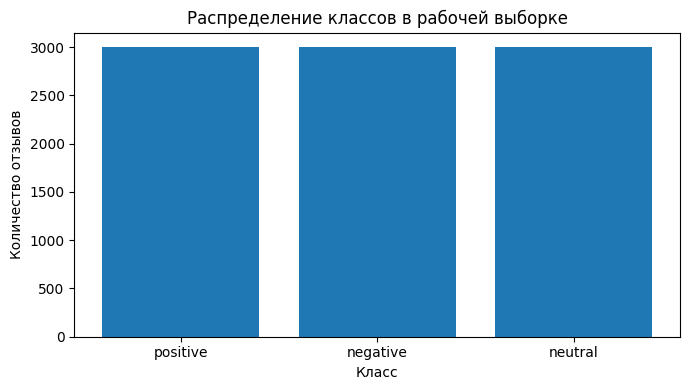

График сохранен: outputs/sentiment_distribution.png


In [42]:
#здесь задается распределение классов(вспомогательная функция для отчета)

class_distribution = (
    df_sample["label_name"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

class_distribution_path = os.path.join(OUTPUT_DIR, "class_distribution.csv")
class_distribution.to_csv(class_distribution_path, index=False, encoding="utf-8-sig")

print(class_distribution)

text_len                   word_count                 
                  mean median min    max       mean median min   max
label_name                                                          
negative    707.975000  479.5  21  27201    112.180   76.0   2  3710
neutral     921.165667  520.5  21  33773    137.700   78.0   3  4243
positive    719.161333  472.0  13  35711    107.027   71.0   1  4909

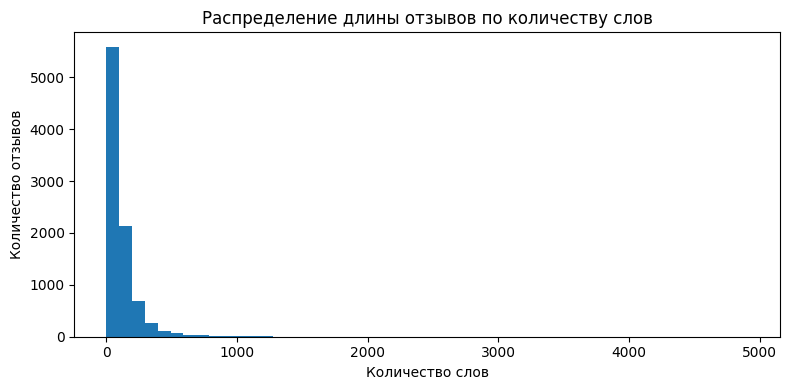

Статистика сохранена: outputs/length_stats.csv
График сохранен: outputs/review_length_distribution.png


In [43]:
# анализируется длины отзывов для создания графика распределения

df_sample["text_len"] = df_sample["text"].str.len()
df_sample["word_count"] = df_sample["text"].str.split().str.len()

length_stats = df_sample.groupby("label_name")[["text_len", "word_count"]].agg(["mean", "median", "min", "max"])
length_stats_path = os.path.join(OUTPUT_DIR, "length_stats.csv")
length_stats.to_csv(length_stats_path, encoding="utf-8-sig")

display(length_stats)

plt.figure(figsize=(8, 4))
plt.hist(df_sample["word_count"], bins=50)
plt.title("Распределение длины отзывов по количеству слов")
plt.xlabel("Количество слов")
plt.ylabel("Количество отзывов")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "review_length_distribution.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Статистика сохранена: {length_stats_path}")
print(f"График сохранен: {plot_path}")

## 4. Разделение данных на тестовый и обучаемый наборы

Используем стратифицированное разделение, чтобы в тестовой и обучающей выборках сохранилось примерно одинаковое распределение классов. По стандарту: 20/80


In [44]:
# делим на 2 набора

X = df_sample["text"]
y = df_sample["label_name"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Размер train:", X_train.shape[0])
print("Размер test:", X_test.shape[0])
print("\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nРаспределение классов в test:")
print(y_test.value_counts(normalize=True).round(3))

Размер train: 7200
Размер test: 1800

Распределение классов в train:
label_name
positive    0.333
negative    0.333
neutral     0.333
Name: proportion, dtype: float64

Распределение классов в test:
label_name
neutral     0.333
negative    0.333
positive    0.333
Name: proportion, dtype: float64


## 5. Эксперимент№1: TF-IDF + Logistic Regression

Это базовая модель. Она нужна для того чтобы оценить, насколько полезны BERT-эмбеддинги, по сравнению с простым TF-IDF. В данном эксперименте текст превращается в разреженный вектор TF-IDF, после чего обучается логистическая регрессия


In [45]:
# обучение базовой модели

baseline_model = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

print("Бейзлайн обучен")

Бейзлайн обучен


In [46]:
# оценка модели на accuracy macro F1

labels_order = ["negative", "neutral", "positive"]

accuracy = accuracy_score(y_test, y_pred_baseline)
macro_f1 = f1_score(y_test, y_pred_baseline, average="macro")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_baseline, labels=labels_order, zero_division=0))

# сохранение подробного отчета по классам для отчета
report_dict = classification_report(
    y_test,
    y_pred_baseline,
    labels=labels_order,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_path = os.path.join(OUTPUT_DIR, "baseline_classification_report.csv")
report_df.to_csv(report_path, encoding="utf-8-sig")

# Сохраняем краткие метрики для будущего сравнения с BERT.
metrics_df = pd.DataFrame([{
    "model": "TF-IDF + Logistic Regression",
    "accuracy": accuracy,
    "macro_f1": macro_f1,
}])
metrics_path = os.path.join(OUTPUT_DIR, "baseline_metrics.csv")
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")

print(f"Подробный отчет сохранен: {report_path}")
print(f"Краткие метрики сохранены: {metrics_path}")

Accuracy: 0.7078
Macro F1: 0.7054

Classification report:
              precision    recall  f1-score   support

    negative       0.74      0.79      0.77       600
     neutral       0.65      0.75      0.70       600
    positive       0.74      0.58      0.65       600

    accuracy                           0.71      1800
   macro avg       0.71      0.71      0.71      1800
weighted avg       0.71      0.71      0.71      1800

Подробный отчет сохранен: outputs/baseline_classification_report.csv
Краткие метрики сохранены: outputs/baseline_metrics.csv


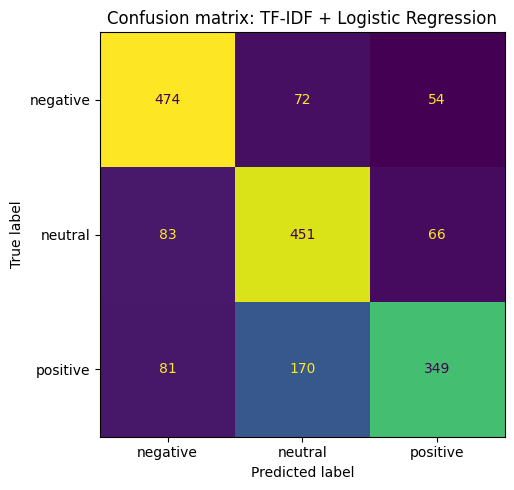

Confusion matrix сохранена: outputs/confusion_matrix_baseline.png


In [47]:
# матрица ошибок для TF-IDF

cm = confusion_matrix(y_test, y_pred_baseline, labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, values_format="d", colorbar=False)
plt.title("Confusion matrix: TF-IDF + Logistic Regression")
plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix_baseline.png")
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Confusion matrix сохранена: {cm_path}")

In [48]:
#сохранение результатов для дальнейшего сравнения

predictions_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred_baseline,
})

predictions_df["is_correct"] = predictions_df["true_label"] == predictions_df["predicted_label"]

predictions_path = os.path.join(OUTPUT_DIR, "baseline_predictions_sample.csv")
predictions_df.head(300).to_csv(predictions_path, index=False, encoding="utf-8-sig")

print(f"Примеры предсказаний сохранены: {predictions_path}")
predictions_df.head(10)
#тестовый вывод
print("Базовый этап проекта успешно выполнен.")
print("Первые результаты сохранены в папке outputs.")
print("Список файлов, сохраненных на текущий момент:")
for file_name in sorted(os.listdir(OUTPUT_DIR)):
    print("-", file_name)

Примеры предсказаний сохранены: outputs/baseline_predictions_sample.csv


,text,true_label,predicted_label,is_correct
0,"Чистый отель, близость к метро, приветливый пе...",neutral,neutral,True
1,Начала бороться Я присоединяюсь ко всем возмущ...,negative,negative,True
2,Большое спасибо Были частые боли в животе. Реш...,positive,positive,True
3,Отель крайне простой. Никаких изысков. Но очен...,neutral,neutral,True
4,"Плохо лечат Мне вообще не понравилось, как леч...",negative,negative,True
5,Казахстанский автопром испытывает трудности От...,negative,neutral,False
6,Только по записи Мнение об указанной поликлини...,negative,negative,True
7,просто в восторге от всего - от меню официанто...,negative,positive,False
8,Спасибо врачу Швабриной Татьяне Васильевне Я с...,positive,positive,True
9,"Здравствуйте !!!!! В кафе "" В гостях у Аннушки...",negative,negative,True


## 6. Эксперимент №2: BERT эмбеддинги

В этом проекте BERT используется как нейросетевой энкодер текста. Он работает по примерно такому плану:

1. текст отзыва токенизируется
2. токены подаются в RuBERT
3. из скрытых состояний модели получается один вектор на весь отзыв
4. по этим векторам обучается классификатор кластеров

In [51]:
# настройка библиотек для BERT

import time
import torch

from transformers import AutoTokenizer, AutoModel

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("Дополнительные библиотеки успешно импортированы")
print("CUDA доступна:", torch.cuda.is_available())

Дополнительные библиотеки успешно импортированы
CUDA доступна: True


In [52]:
# настройки для эксперимента BERT

BERT_MODEL_NAME = "DeepPavlov/rubert-base-cased-sentence"
BERT_SAMPLE_PER_CLASS = 1200     # размер подвыборки на класс для BERT-части
BERT_BATCH_SIZE = 32
MAX_LENGTH = 128                 # максимальная длина текста в токенах BERT
N_CLUSTERS = 5                   # желаемое число кластеров для негативных отзывов

# Параметры MLP для классификации кластеров
MLP_HIDDEN_LAYERS = (256, 64)
MLP_MAX_ITER = 200
MLP_ALPHA = 1e-4

print("Модель для эмбеддингов:", BERT_MODEL_NAME)
print("Размер BERT-подвыборки на класс:", BERT_SAMPLE_PER_CLASS)
print("Архитектура MLP:", MLP_HIDDEN_LAYERS)


Модель для эмбеддингов: DeepPavlov/rubert-base-cased-sentence
Размер BERT-подвыборки на класс: 1200
Архитектура MLP: (256, 64)


In [53]:
# создаем отдельную подвыборку для сравнения TF-IDF и BERT

bert_df = (
    df_sample.groupby("label_name", group_keys=False)
    .apply(lambda part: part.sample(n=min(len(part), BERT_SAMPLE_PER_CLASS), random_state=RANDOM_STATE))
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

bert_sample_path = os.path.join(OUTPUT_DIR, "bert_experiment_sample.csv")
bert_df.to_csv(bert_sample_path, index=False, encoding="utf-8-sig")

print("Размер BERT-подвыборки:", bert_df.shape)
print("Распределение классов:")
print(bert_df["label_name"].value_counts())
print(f"BERT-подвыборка сохранена: {bert_sample_path}")

assert bert_df["label_name"].nunique() == 3, "В BERT-подвыборке должны быть все три класса."
assert bert_df.groupby("label_name").size().min() >= 10, "Для устойчивого train/test split нужно хотя бы 10 объектов на класс."

bert_df.head()

Размер BERT-подвыборки: (3600, 6)
Распределение классов:
label_name
neutral     1200
positive    1200
negative    1200
Name: count, dtype: int64
BERT-подвыборка сохранена: outputs/bert_experiment_sample.csv


,text,label_raw,label_name,label,text_len,word_count
0,"где немцы были в августе 1941? ну, и климат за...",0,neutral,0,732,111
1,"Отель, конечно, понравился. Ощущение грандиозн...",0,neutral,0,1108,155
2,Киитос - лучшая стоматология в Мытищах Весной ...,1,positive,1,597,96
3,"Были с мужем в ресторане "" Большой Кавказ "" не...",1,positive,1,444,79
4,Невнимательность врача Обратилась в Квд 21 с с...,2,negative,2,308,45


In [54]:
# создаем обучаемый и тестовый наборы. также сохраняем индексы, чтобы затем брать соответствующие строки из матрицы эмбеддингов

bert_indices = np.arange(len(bert_df))
bert_labels = bert_df["label_name"].values

train_idx, test_idx, y_train_bert, y_test_bert = train_test_split(
    bert_indices,
    bert_labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=bert_labels,
)

print("Размер train для BERT-эксперимента:", len(train_idx))
print("Размер test для BERT-эксперимента:", len(test_idx))

Размер train для BERT-эксперимента: 2880
Размер test для BERT-эксперимента: 720


In [55]:
# для базовой модели TF-IDF берем ту же подвыборку, что и BERT для чистоты экмперимента

X_train_common = bert_df.loc[train_idx, "text"]
X_test_common = bert_df.loc[test_idx, "text"]

common_tfidf_model = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

common_tfidf_model.fit(X_train_common, y_train_bert)
y_pred_tfidf_common = common_tfidf_model.predict(X_test_common)

common_tfidf_accuracy = accuracy_score(y_test_bert, y_pred_tfidf_common)
common_tfidf_macro_f1 = f1_score(y_test_bert, y_pred_tfidf_common, average="macro")

print("TF-IDF на BERT-подвыборке")
print(f"Accuracy: {common_tfidf_accuracy:.4f}")
print(f"Macro F1: {common_tfidf_macro_f1:.4f}")
print(classification_report(y_test_bert, y_pred_tfidf_common, labels=labels_order, zero_division=0))

common_tfidf_metrics = pd.DataFrame([{
    "model": "TF-IDF + Logistic Regression, same sample",
    "accuracy": common_tfidf_accuracy,
    "macro_f1": common_tfidf_macro_f1,
}])

common_tfidf_metrics_path = os.path.join(OUTPUT_DIR, "tfidf_common_sample_metrics.csv")
common_tfidf_metrics.to_csv(common_tfidf_metrics_path, index=False, encoding="utf-8-sig")

print(f"Метрики сохранены: {common_tfidf_metrics_path}")

TF-IDF на BERT-подвыборке
Accuracy: 0.6986
Macro F1: 0.6970
              precision    recall  f1-score   support

    negative       0.69      0.75      0.72       240
     neutral       0.65      0.76      0.70       240
    positive       0.79      0.58      0.67       240

    accuracy                           0.70       720
   macro avg       0.71      0.70      0.70       720
weighted avg       0.71      0.70      0.70       720

Метрики сохранены: outputs/tfidf_common_sample_metrics.csv


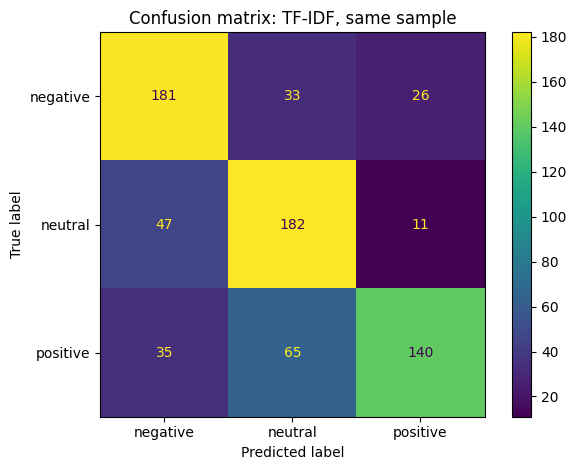

График сохранен: outputs/confusion_matrix_tfidf_common_sample.png


In [56]:
# матрица ошибок для TF-IDF на общей подвыборке

cm_tfidf_common = confusion_matrix(y_test_bert, y_pred_tfidf_common, labels=labels_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf_common, display_labels=labels_order)
disp.plot(values_format="d")
plt.title("Confusion matrix: TF-IDF, same sample")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "confusion_matrix_tfidf_common_sample.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"График сохранен: {plot_path}")

## 7. Получение BERT эмбеддингов

Ниже реализована функция, которая превращает список отзывов в матрицу эмбеддингов. Каждая строка матрицы — это один отзыв, представленный числовым вектором.

Для получения одного вектора на весь отзыв используется mean pooling: усреднение скрытых состояний токенов с учетом attention mask. Attention mask нужна, чтобы при усреднении не учитывать служебные padding-токены.

In [57]:
# загрузка токенизатора и модели RuBERT

start_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

try:
    tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME)
except Exception as exc:
    raise RuntimeError(
        "Не удалось загрузить RuBERT из Hugging Face. "
        "Проверьте подключение к интернету в Colab и название модели BERT_MODEL_NAME. "
        f"Текущее значение: {BERT_MODEL_NAME}"
    ) from exc

bert_model.to(device)
bert_model.eval()

print(f"RuBERT загружен за {time.time() - start_time:.1f} секунд")

Используемое устройство: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RuBERT загружен за 3.2 секунд


In [58]:
# реализация функции для получения эмбеддингов

#функция превращает скрытые состояния токенов в один вектор предложения, не учитывая padding токены, тк в нет них смысла
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

#функция кодирует список текстов в BERT эмбеддинги, работая батчами
@torch.no_grad()
def encode_texts_with_bert(texts, batch_size=BERT_BATCH_SIZE, max_length=MAX_LENGTH):
    all_embeddings = []
    texts = list(texts)
    total = len(texts)

    for start in range(0, total, batch_size):
        batch_texts = texts[start:start + batch_size]

        encoded_input = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded_input = {key: value.to(device) for key, value in encoded_input.items()}

        model_output = bert_model(**encoded_input)
        batch_embeddings = mean_pooling(model_output, encoded_input["attention_mask"])
        batch_embeddings = batch_embeddings.cpu().numpy()
        all_embeddings.append(batch_embeddings)

        if (start // batch_size + 1) % 10 == 0 or start + batch_size >= total:
            print(f"Обработано {min(start + batch_size, total)} из {total} текстов")

    return np.vstack(all_embeddings)


print("Функции для эмбеддингов готовы")

Функции для эмбеддингов готовы


In [59]:
# кодирование всех отзывы из подвыборки для BERT

start_time = time.time()

embedding_path = os.path.join(OUTPUT_DIR, "bert_embeddings.npy")

if os.path.exists(embedding_path):
    bert_embeddings = np.load(embedding_path)
    print(f"Эмбеддинги загружены из файла: {embedding_path}")
else:
    bert_embeddings = encode_texts_with_bert(bert_df["text"].tolist())
    np.save(embedding_path, bert_embeddings)
    print(f"Эмбеддинги сохранены: {embedding_path}")

print("Размер матрицы эмбеддингов:", bert_embeddings.shape)
print(f"Время блока кодирования: {(time.time() - start_time) / 60:.2f} минут")

assert bert_embeddings.shape[0] == len(bert_df), "Число эмбеддингов должно совпадать с числом отзывов."
assert bert_embeddings.ndim == 2, "Матрица эмбеддингов должна быть двумерной."

Эмбеддинги загружены из файла: outputs/bert_embeddings.npy
Размер матрицы эмбеддингов: (3600, 768)
Время блока кодирования: 0.00 минут


In [60]:
# обучаем классификатор на BERT эмбеддингах

X_train_emb = bert_embeddings[train_idx]
X_test_emb = bert_embeddings[test_idx]

#здесь происходит масштабирование для линейного классификатора, нужно для плотных эмбеддингов
scaler = StandardScaler()
X_train_emb_scaled = scaler.fit_transform(X_train_emb)
X_test_emb_scaled = scaler.transform(X_test_emb)

bert_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

bert_clf.fit(X_train_emb_scaled, y_train_bert)
y_pred_bert = bert_clf.predict(X_test_emb_scaled)
y_proba_bert = bert_clf.predict_proba(X_test_emb_scaled)

bert_accuracy = accuracy_score(y_test_bert, y_pred_bert)
bert_macro_f1 = f1_score(y_test_bert, y_pred_bert, average="macro")

print("RuBERT embeddings + Logistic Regression")
print(f"Accuracy: {bert_accuracy:.4f}")
print(f"Macro F1: {bert_macro_f1:.4f}")
print(classification_report(y_test_bert, y_pred_bert, labels=labels_order, zero_division=0))

RuBERT embeddings + Logistic Regression
Accuracy: 0.6375
Macro F1: 0.6367
              precision    recall  f1-score   support

    negative       0.68      0.72      0.70       240
     neutral       0.61      0.60      0.60       240
    positive       0.62      0.60      0.61       240

    accuracy                           0.64       720
   macro avg       0.64      0.64      0.64       720
weighted avg       0.64      0.64      0.64       720



In [61]:
# сохранение BERT классификатора для дальнейшего анализа

bert_report_dict = classification_report(
    y_test_bert,
    y_pred_bert,
    labels=labels_order,
    output_dict=True,
    zero_division=0,
)
bert_report_df = pd.DataFrame(bert_report_dict).T
bert_report_path = os.path.join(OUTPUT_DIR, "bert_classification_report.csv")
bert_report_df.to_csv(bert_report_path, encoding="utf-8-sig")

bert_metrics = pd.DataFrame([{
    "model": "RuBERT embeddings + Logistic Regression",
    "accuracy": bert_accuracy,
    "macro_f1": bert_macro_f1,
}])
bert_metrics_path = os.path.join(OUTPUT_DIR, "bert_metrics.csv")
bert_metrics.to_csv(bert_metrics_path, index=False, encoding="utf-8-sig")

print(f"Подробный отчет сохранен: {bert_report_path}")
print(f"Краткие метрики сохранены: {bert_metrics_path}")

Подробный отчет сохранен: outputs/bert_classification_report.csv
Краткие метрики сохранены: outputs/bert_metrics.csv


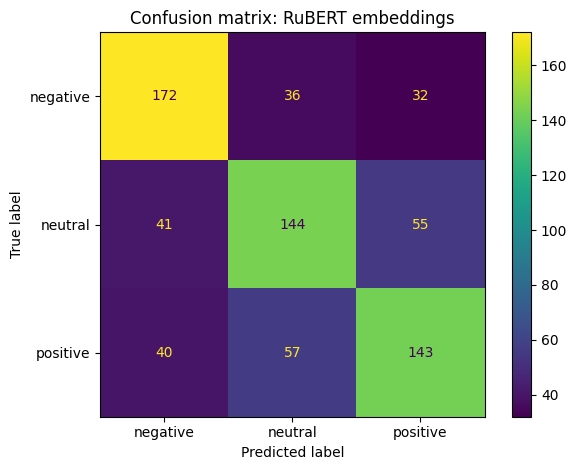

График сохранен: outputs/confusion_matrix_bert.png


In [62]:
# матрица ошибок для BERT классификатора

cm_bert = confusion_matrix(y_test_bert, y_pred_bert, labels=labels_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=labels_order)
disp.plot(values_format="d")
plt.title("Confusion matrix: RuBERT embeddings")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "confusion_matrix_bert.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"График сохранен: {plot_path}")

## 8. Эксперимент №3: MLP классификатор на BERT эмбеддингах

В этом эксперименте используются те же BERT-эмбеддинги, что и в предыдущем блоке, но вместо логистической регрессии обучается небольшая полносвязная нейронная сеть. Это нужно, чтобы в работе был отдельный нейросетевой классификатор, а не только использование готовой BERT-модели как источника признаков

In [63]:
# обучение MLP-классификатора на BERT-эмбеддингах
# на вход подаются не тексты, а уже предобработанные BERT векторы

# для MLP кодируем метки в числа, а после предсказания возвращаем их обратно в строки, тк иногда могут быть ошибки, если так не сделать

mlp_label_encoder = LabelEncoder()

y_train_mlp = mlp_label_encoder.fit_transform(y_train_bert)
y_test_mlp = mlp_label_encoder.transform(y_test_bert)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=MLP_HIDDEN_LAYERS,
    activation="relu",
    solver="adam",
    alpha=MLP_ALPHA,
    batch_size=64,
    learning_rate="adaptive",
    max_iter=MLP_MAX_ITER,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RANDOM_STATE,
)

mlp_clf.fit(X_train_emb_scaled, y_train_mlp)

# MLP возвращает числовые классы(0,1,2)

y_pred_mlp_encoded = mlp_clf.predict(X_test_emb_scaled)
y_pred_mlp = mlp_label_encoder.inverse_transform(y_pred_mlp_encoded.astype(int))

y_proba_mlp = mlp_clf.predict_proba(X_test_emb_scaled)

mlp_accuracy = accuracy_score(y_test_bert, y_pred_mlp)
mlp_macro_f1 = f1_score(y_test_bert, y_pred_mlp, average="macro")

print("RuBERT embeddings + MLP")
print(f"Accuracy: {mlp_accuracy:.4f}")
print(f"Macro F1: {mlp_macro_f1:.4f}")

print(
    classification_report(
        y_test_bert,
        y_pred_mlp,
        labels=labels_order,
        zero_division=0
    )
)


RuBERT embeddings + MLP
Accuracy: 0.6667
Macro F1: 0.6658
              precision    recall  f1-score   support

    negative       0.72      0.75      0.73       240
     neutral       0.62      0.61      0.62       240
    positive       0.66      0.63      0.65       240

    accuracy                           0.67       720
   macro avg       0.67      0.67      0.67       720
weighted avg       0.67      0.67      0.67       720



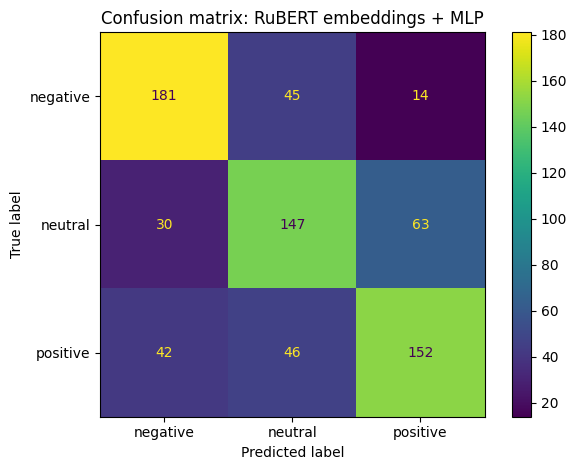

Подробный отчет MLP сохранен: outputs/mlp_classification_report.csv
Краткие метрики MLP сохранены: outputs/mlp_metrics.csv
Матрица ошибок MLP сохранена: outputs/confusion_matrix_mlp.png


In [64]:
# сохраняем метрики и матрицу ошибок для MLP

mlp_report_dict = classification_report(
    y_test_bert,
    y_pred_mlp,
    labels=labels_order,
    output_dict=True,
    zero_division=0,
)
mlp_report_df = pd.DataFrame(mlp_report_dict).T
mlp_report_path = os.path.join(OUTPUT_DIR, "mlp_classification_report.csv")
mlp_report_df.to_csv(mlp_report_path, encoding="utf-8-sig")

mlp_metrics = pd.DataFrame([{
    "model": "RuBERT embeddings + MLP",
    "accuracy": mlp_accuracy,
    "macro_f1": mlp_macro_f1,
}])
mlp_metrics_path = os.path.join(OUTPUT_DIR, "mlp_metrics.csv")
mlp_metrics.to_csv(mlp_metrics_path, index=False, encoding="utf-8-sig")

cm_mlp = confusion_matrix(y_test_bert, y_pred_mlp, labels=labels_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=labels_order)
disp.plot(values_format="d")
plt.title("Confusion matrix: RuBERT embeddings + MLP")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "confusion_matrix_mlp.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Подробный отчет MLP сохранен: {mlp_report_path}")
print(f"Краткие метрики MLP сохранены: {mlp_metrics_path}")
print(f"Матрица ошибок MLP сохранена: {plot_path}")


,model,accuracy,macro_f1
0,"TF-IDF + Logistic Regression, same sample",0.698611,0.697048
1,RuBERT embeddings + Logistic Regression,0.637500,0.636684
2,RuBERT embeddings + MLP,0.666667,0.665843


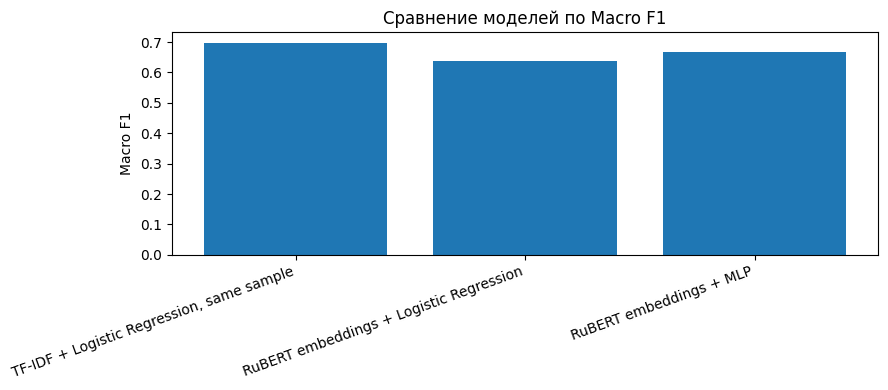

Таблица сравнения сохранена: outputs/model_comparison.csv
График сравнения сохранен: outputs/model_comparison_macro_f1.png


In [65]:
# Сравнение всех трех моделей на одной и той же BERT-подвыборке в виде таблицы

model_comparison = pd.concat([common_tfidf_metrics, bert_metrics, mlp_metrics], ignore_index=True)
comparison_path = os.path.join(OUTPUT_DIR, "model_comparison.csv")
model_comparison.to_csv(comparison_path, index=False, encoding="utf-8-sig")

display(model_comparison)

plt.figure(figsize=(9, 4))
plt.bar(model_comparison["model"], model_comparison["macro_f1"])
plt.title("Сравнение моделей по Macro F1")
plt.ylabel("Macro F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "model_comparison_macro_f1.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Таблица сравнения сохранена: {comparison_path}")
print(f"График сравнения сохранен: {plot_path}")


In [66]:
# сохраняем примеры предсказаний модели BERT

bert_test_results = bert_df.loc[test_idx, ["text", "label_name"]].copy()
bert_test_results["predicted_label"] = y_pred_bert
bert_test_results["confidence"] = y_proba_bert.max(axis=1)
bert_test_results["is_correct"] = bert_test_results["label_name"] == bert_test_results["predicted_label"]

bert_predictions_path = os.path.join(OUTPUT_DIR, "bert_predictions_sample.csv")
bert_test_results.head(100).to_csv(bert_predictions_path, index=False, encoding="utf-8-sig")

print(f"Примеры предсказаний сохранены: {bert_predictions_path}")
bert_test_results.head(10)

Примеры предсказаний сохранены: outputs/bert_predictions_sample.csv


,text,label_name,predicted_label,confidence,is_correct
3435,"Прекрасное местоположение, хороший, но дорогой...",positive,neutral,0.998944,False
1856,рохожих заставляют разуваться и ходить по улиц...,negative,neutral,0.788949,False
1670,"Тебя ебет? Она тебя вроде не трогает, зачем ле...",negative,negative,0.998353,True
1399,Купили ВАЗ 2107 в 2009 году в автосалоне.Эта н...,neutral,negative,0.383825,False
964,алее немного времени (20-40 лет) и опухоль рас...,positive,positive,0.921193,True
3369,"19.01.2013 Отмечали ДР девишником , всё ок , т...",positive,negative,0.558581,False
1048,Были с женой на праздничных днях в Санкт-Петер...,positive,neutral,0.737055,False
694,Благодарность врачам гинекологического отделен...,positive,positive,0.999957,True
1549,"Очень приятно, что вы заметили фото. Зато тетя...",neutral,positive,0.488358,False
1171,Огромная благодарность Радченко Екатерина Влад...,positive,positive,0.999936,True


In [67]:
# анализируем и сохраняем ошибки BERT модели для дальнейшего анализа

bert_errors = bert_test_results[~bert_test_results["is_correct"]].copy()
bert_errors_path = os.path.join(OUTPUT_DIR, "bert_errors_for_analysis.csv")
bert_errors.head(100).to_csv(bert_errors_path, index=False, encoding="utf-8-sig")

print("Количество ошибок на тестовой выборке:", len(bert_errors))
print(f"Ошибки сохранены: {bert_errors_path}")

bert_errors.head(10)

Количество ошибок на тестовой выборке: 261
Ошибки сохранены: outputs/bert_errors_for_analysis.csv


,text,label_name,predicted_label,confidence,is_correct
3435,"Прекрасное местоположение, хороший, но дорогой...",positive,neutral,0.998944,False
1856,рохожих заставляют разуваться и ходить по улиц...,negative,neutral,0.788949,False
1399,Купили ВАЗ 2107 в 2009 году в автосалоне.Эта н...,neutral,negative,0.383825,False
3369,"19.01.2013 Отмечали ДР девишником , всё ок , т...",positive,negative,0.558581,False
1048,Были с женой на праздничных днях в Санкт-Петер...,positive,neutral,0.737055,False
1549,"Очень приятно, что вы заметили фото. Зато тетя...",neutral,positive,0.488358,False
142,Проживали в отеле с 14 по 21 июля 2015 года!! ...,positive,neutral,0.676614,False
336,Дама с 8-го столика которая отдыхала 15 января...,negative,positive,0.774364,False
1228,Доброго времени суток . 18 августа 2012 отмети...,positive,negative,0.636655,False
2087,"alau.kz 08 ноября 2016, 21:46 alau.kz Происшес...",neutral,negative,0.997912,False


## 9. Кластеризация негативных отзывов

Классификация отвечает на вопрос: отзыв позитивный, нейтральный или негативный.

Но нам также нужно понять, какие именно проблемы повторяются в негативных отзывах. Поэтому дальше выполняется кластеризация негативных отзывов по BERT-эмбеддингам.

Модель группирует похожие негативные отзывы, а затем для каждого кластера строится краткая интерпретация и возможное управленческое действие

In [68]:
# выделяем негативные отзывы и их эмбеддинги

negative_mask = bert_df["label_name"] == "negative"
negative_df = bert_df[negative_mask].copy().reset_index(drop=False)  # старый индекс здесь нужен нам для связи с матрицей эмбеддингов
negative_embeddings = bert_embeddings[negative_df["index"].values]

print("Количество негативных отзывов для кластеризации:", len(negative_df))
print("Размер матрицы негативных эмбеддингов:", negative_embeddings.shape)

Количество негативных отзывов для кластеризации: 1200
Размер матрицы негативных эмбеддингов: (1200, 768)


In [69]:
# используем KMeans для кластеризации негативных отзывов

assert len(negative_df) >= 3, "Для кластеризации нужно хотя бы 3 негативных отзыва."

# чтобы KMeans не сломался из-за n_clusters > n_samples делаем проверку
actual_n_clusters = min(N_CLUSTERS, len(negative_df) - 1)
actual_n_clusters = max(2, actual_n_clusters)
print(f"Фактическое число кластеров: {actual_n_clusters}")

# Для KMeans масштабируем эмбеддинги для лучшей работы
cluster_scaler = StandardScaler()
negative_embeddings_scaled = cluster_scaler.fit_transform(negative_embeddings)

kmeans = KMeans(
    n_clusters=actual_n_clusters,
    random_state=RANDOM_STATE,
    n_init=10,
)

negative_df["cluster"] = kmeans.fit_predict(negative_embeddings_scaled)

# Silhouette score помогает формально оценить разделимость кластеров: чем выше значение, тем реже кластеры перекрываются
if len(set(negative_df["cluster"])) > 1 and len(negative_df) > actual_n_clusters:
    sil_score = silhouette_score(negative_embeddings_scaled, negative_df["cluster"])
else:
    sil_score = np.nan

print("Размеры кластеров:")
print(negative_df["cluster"].value_counts().sort_index())
print(f"Silhouette score: {sil_score:.4f}" if not np.isnan(sil_score) else "Silhouette score: не рассчитан")

clustered_path = os.path.join(OUTPUT_DIR, "negative_reviews_clustered.csv")
negative_df[["text", "label", "label_name", "cluster"]].to_csv(clustered_path, index=False, encoding="utf-8-sig")
print(f"Негативные отзывы с кластерами сохранены: {clustered_path}")

Фактическое число кластеров: 5
Размеры кластеров:
cluster
0     73
1    192
2    222
3    249
4    464
Name: count, dtype: int64
Silhouette score: 0.1096
Негативные отзывы с кластерами сохранены: outputs/negative_reviews_clustered.csv


In [70]:
# выделяем характерные слова и словосочетания для каждого кластера


def top_terms_by_cluster(df, text_col="text", cluster_col="cluster", n_terms=10):
    """
    Для каждого кластера ищем слова/словосочетания с наибольшим средним TF-IDF.
    Это нужно не для обучения модели, а для интерпретации кластеров в отчете.
    """
    vectorizer = TfidfVectorizer(
        max_features=7000,
        ngram_range=(1, 2),
        min_df=1,   # тк надежнее для небольших кластеров
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(df[text_col])
        terms = np.array(vectorizer.get_feature_names_out())
    except ValueError:
        # эта проверка нужна на случай, когда после очистки в каком-то искусственно маленьком примере не осталось слов
        return pd.DataFrame({
            "cluster": sorted(df[cluster_col].unique()),
            "top_terms": [""] * df[cluster_col].nunique(),
            "count": [int((df[cluster_col] == c).sum()) for c in sorted(df[cluster_col].unique())],
        })

    rows = []
    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_mask = df[cluster_col].values == cluster_id
        mean_tfidf = np.asarray(tfidf_matrix[cluster_mask].mean(axis=0)).ravel()
        top_indices = mean_tfidf.argsort()[::-1][:n_terms]
        top_terms = terms[top_indices].tolist()
        rows.append({
            "cluster": cluster_id,
            "top_terms": ", ".join(top_terms),
            "count": int(cluster_mask.sum()),
        })

    return pd.DataFrame(rows)


cluster_terms = top_terms_by_cluster(negative_df, n_terms=12)
display(cluster_terms)

,cluster,top_terms,count
0,0,"ты, не, на, так, то, или, как, да, это, что, з...",73
1,1,"очень, спасибо, все, обслуживание, на, вкусно,...",192
2,2,"не, на, что, по, но, за, это, то, как, из, все...",222
3,3,"не, на, что, как, это, по, просто, но, нет, ни...",249
4,4,"не, на, что, мне, врач, меня, как, это, по, вс...",464


In [71]:
# пытемся сделать простую интерпретацию кластеров и рекомендуемые действия к ним

ACTION_RULES = [
    {
        "topic": "Сервис и коммуникация",
        "keywords": ["персонал", "сервис", "официант", "сотрудник", "менеджер", "поддержка", "хам", "груб", "общение"],
        "action": "Проверить качество коммуникации сотрудников с клиентами и провести разбор негативных обращений.",
    },
    {
        "topic": "Скорость и ожидание",
        "keywords": ["долго", "ждать", "ждали", "ожидание", "час", "время", "очередь", "медленно", "срок"],
        "action": "Проверить узкие места в процессе обслуживания или доставки и сократить время ожидания.",
    },
    {
        "topic": "Цена и ценность",
        "keywords": ["цена", "дорого", "стоимость", "деньги", "оплата", "переплата", "дешевле"],
        "action": "Проверить восприятие цены клиентами и сопоставить стоимость с качеством продукта или услуги.",
    },
    {
        "topic": "Качество продукта или услуги",
        "keywords": ["качество", "плохой", "ужасный", "слом", "гряз", "вкус", "товар", "номер", "еда", "работает"],
        "action": "Проверить качество продукта или услуги, найти повторяющиеся дефекты и передать их ответственным подразделениям.",
    },
    {
        "topic": "Доставка и выполнение заказа",
        "keywords": ["доставка", "заказ", "курьер", "привез", "отправ", "получил", "посылка", "заброниров"],
        "action": "Проверить процесс выполнения заказов, доставки и информирования клиента о статусе.",
    },
]

# эта функция подбирает интерпретацию кластера по ключевым словам
def infer_topic_and_action(top_terms, example_texts):
    combined_text = (str(top_terms) + " " + " ".join(map(str, example_texts))).lower()

    best_rule = None
    best_score = 0
    for rule in ACTION_RULES:
        score = sum(1 for keyword in rule["keywords"] if keyword in combined_text)
        if score > best_score:
            best_score = score
            best_rule = rule

    if best_rule is None:
        return "Смешанная группа проблем", "Просмотреть примеры отзывов внутри кластера и вручную уточнить тип проблемы."

    return best_rule["topic"], best_rule["action"]


summary_rows = []
for cluster_id in sorted(negative_df["cluster"].unique()):
    cluster_part = negative_df[negative_df["cluster"] == cluster_id].copy()
    top_terms = cluster_terms.loc[cluster_terms["cluster"] == cluster_id, "top_terms"].iloc[0]
    examples = cluster_part["text"].head(3).tolist()
    topic, action = infer_topic_and_action(top_terms, examples)

    summary_rows.append({
        "cluster": cluster_id,
        "count": len(cluster_part),
        "share_of_negative": len(cluster_part) / len(negative_df),
        "top_terms": top_terms,
        "interpreted_topic": topic,
        "recommended_action": action,
        "example_1": examples[0] if len(examples) > 0 else "",
        "example_2": examples[1] if len(examples) > 1 else "",
        "example_3": examples[2] if len(examples) > 2 else "",
    })

cluster_summary = pd.DataFrame(summary_rows)
cluster_summary_path = os.path.join(OUTPUT_DIR, "negative_cluster_summary.csv")
cluster_summary.to_csv(cluster_summary_path, index=False, encoding="utf-8-sig")

display(cluster_summary)
print(f"Сводка кластеров сохранена: {cluster_summary_path}")

,cluster,count,share_of_negative,top_terms,interpreted_topic,recommended_action,example_1,example_2,example_3
0,0,73,0.060833,"ты, не, на, так, то, или, как, да, это, что, з...",Сервис и коммуникация,Проверить качество коммуникации сотрудников с ...,"Хочу поделиться с вами эмоциями , полученными ...",РЕгистратура КВД № 9 Грубое отношение работник...,"Пидрюльк, не вмешивайся в разговор, иди пощитп..."
1,1,192,0.160000,"очень, спасибо, все, обслуживание, на, вкусно,...",Сервис и коммуникация,Проверить качество коммуникации сотрудников с ...,"Бываем там с друзьями , правда уже после обиль...","Уютно посидеть и поболтать , да ещё и вкусно п...","Мне кажется , в Трикстере можно вообще бесконе..."
2,2,222,0.185000,"не, на, что, по, но, за, это, то, как, из, все...",Качество продукта или услуги,"Проверить качество продукта или услуги, найти ...","Бассейн закрывается в 20:00 , бар у бассейна о...",Отпраздновали в Белом береге свадьбу летом 200...,Таинственным образом появляются записи А в кар...
3,3,249,0.207500,"не, на, что, как, это, по, просто, но, нет, ни...",Сервис и коммуникация,Проверить качество коммуникации сотрудников с ...,"Я был очарован фотографиями этого курорта, опу...","Очередной пердун в лужу, смотри не обосрись. П...","Ужас , ужас , ужас !!! Была там в воскресенье ..."
4,4,464,0.386667,"не, на, что, мне, врач, меня, как, это, по, вс...",Доставка и выполнение заказа,"Проверить процесс выполнения заказов, доставки...",Невнимательность врача Обратилась в Квд 21 с с...,Неправильно поставили диагноз Ребенок сломал р...,Будьте бдительны Эта бестолочь от медицины не ...


Сводка кластеров сохранена: outputs/negative_cluster_summary.csv


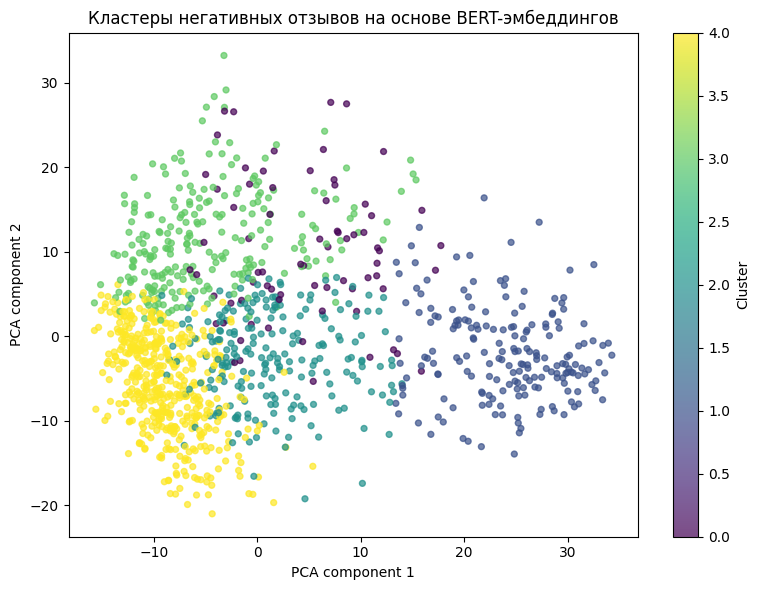

Визуализация кластеров сохранена: outputs/negative_clusters_pca.png


In [72]:
# визуализируем кластеры негативных отзывов через PCA: она снижает размерность BERT векторов до 2 координат, чтобы их можно было легко показать на графике

pca = PCA(n_components=2, random_state=RANDOM_STATE)
negative_2d = pca.fit_transform(negative_embeddings_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    negative_2d[:, 0],
    negative_2d[:, 1],
    c=negative_df["cluster"],
    alpha=0.7,
    s=18,
)
plt.title("Кластеры негативных отзывов на основе BERT-эмбеддингов")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "negative_clusters_pca.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Визуализация кластеров сохранена: {plot_path}")

In [73]:
# Строим интерпретационную таблицу: берем лучшую из обученных моделей по оценке macro F1, применяем ее ко всей BERT-подвыборке и смотрим,
# какие отзывы она относит к разным классам. Для отзывов, которые модель считает негативными, дополнительно указывается ближайший кластер.

if mlp_macro_f1 > bert_macro_f1:
    best_classifier_name = "RuBERT embeddings + MLP"
    best_classifier = mlp_clf
    best_classifier_type = "mlp"
else:
    best_classifier_name = "RuBERT embeddings + Logistic Regression"
    best_classifier = bert_clf
    best_classifier_type = "logreg"

print("Лучшая модель для интерпретационной таблицы:", best_classifier_name)

all_embeddings_scaled = scaler.transform(bert_embeddings)

# для логистической регрессии predict сразу возвращает строковые метки,
# в то время как для MLP predict нужно сначала декодировать обратно в метки

if best_classifier_type == "mlp":
    all_pred_encoded = best_classifier.predict(all_embeddings_scaled)
    all_pred_labels = mlp_label_encoder.inverse_transform(all_pred_encoded.astype(int))
else:
    all_pred_labels = best_classifier.predict(all_embeddings_scaled)

all_pred_proba = best_classifier.predict_proba(all_embeddings_scaled)
all_confidence = all_pred_proba.max(axis=1)

# для предсказанных негативных отзывов определяем ближайший кластер
all_clusters = np.full(shape=len(bert_df), fill_value=-1, dtype=int)
pred_negative_mask = all_pred_labels == "negative"
if pred_negative_mask.sum() > 0:
    pred_negative_embeddings_scaled = cluster_scaler.transform(bert_embeddings[pred_negative_mask])
    all_clusters[pred_negative_mask] = kmeans.predict(pred_negative_embeddings_scaled)

cluster_to_action = cluster_summary.set_index("cluster")["recommended_action"].to_dict()
cluster_to_topic = cluster_summary.set_index("cluster")["interpreted_topic"].to_dict()

# эта функция нужна для названия кластера в итоговой таблице(подбирает короткую интерпретацию)
def action_for_row(pred_label, cluster_id):
    if pred_label == "positive":
        return "Положительная оценка: можно использовать как пример удачного опыта."
    if pred_label == "neutral":
        return "Нейтральная оценка: отзыв полезен для мониторинга, но не содержит сильного сигнала."
    if pred_label == "negative" and cluster_id in cluster_to_action:
        return cluster_to_action[cluster_id]
    return "Нужна ручная проверка отзыва."

# эта функция работает в паре с той: выдает навзание для класса
def topic_for_row(pred_label, cluster_id):
    if pred_label == "positive":
        return "Положительный опыт"
    if pred_label == "neutral":
        return "Нейтральный отзыв"
    if pred_label == "negative" and cluster_id in cluster_to_topic:
        return cluster_to_topic[cluster_id]
    return "Требует ручной проверки"


interpretation_table = bert_df[["text", "label_name"]].copy()
interpretation_table = interpretation_table.rename(columns={"label_name": "true_label"})
interpretation_table["best_model"] = best_classifier_name
interpretation_table["predicted_sentiment"] = all_pred_labels
interpretation_table["confidence"] = all_confidence.round(4)
interpretation_table["problem_cluster"] = all_clusters
interpretation_table["interpreted_topic"] = [
    topic_for_row(label, cluster) for label, cluster in zip(all_pred_labels, all_clusters)
]
interpretation_table["interpretation"] = [
    action_for_row(label, cluster) for label, cluster in zip(all_pred_labels, all_clusters)
]

interpretation_table_path = os.path.join(OUTPUT_DIR, "interpretation_table_full.csv")
interpretation_table_sample_path = os.path.join(OUTPUT_DIR, "interpretation_table_sample.csv")

interpretation_table.to_csv(interpretation_table_path, index=False, encoding="utf-8-sig")
interpretation_table.head(100).to_csv(interpretation_table_sample_path, index=False, encoding="utf-8-sig")

print(f"Полная интерпретационная таблица сохранена: {interpretation_table_path}")
print(f"Пример интерпретационной таблицы сохранен: {interpretation_table_sample_path}")

interpretation_table.head(10)


Лучшая модель для интерпретационной таблицы: RuBERT embeddings + MLP
Полная интерпретационная таблица сохранена: outputs/interpretation_table_full.csv
Пример интерпретационной таблицы сохранен: outputs/interpretation_table_sample.csv


,text,true_label,best_model,predicted_sentiment,confidence,problem_cluster,interpreted_topic,interpretation
0,"где немцы были в августе 1941? ну, и климат за...",neutral,RuBERT embeddings + MLP,neutral,0.5126,-1,Нейтральный отзыв,Нейтральная оценка: отзыв полезен для монитори...
1,"Отель, конечно, понравился. Ощущение грандиозн...",neutral,RuBERT embeddings + MLP,neutral,0.8810,-1,Нейтральный отзыв,Нейтральная оценка: отзыв полезен для монитори...
2,Киитос - лучшая стоматология в Мытищах Весной ...,positive,RuBERT embeddings + MLP,positive,0.6813,-1,Положительный опыт,Положительная оценка: можно использовать как п...
3,"Были с мужем в ресторане "" Большой Кавказ "" не...",positive,RuBERT embeddings + MLP,negative,0.6047,1,Сервис и коммуникация,Проверить качество коммуникации сотрудников с ...
4,Невнимательность врача Обратилась в Квд 21 с с...,negative,RuBERT embeddings + MLP,negative,0.9996,4,Доставка и выполнение заказа,"Проверить процесс выполнения заказов, доставки..."
5,Высококачественно и быстро работающая лаборато...,positive,RuBERT embeddings + MLP,positive,0.5910,-1,Положительный опыт,Положительная оценка: можно использовать как п...
6,гомоцистеином по-видимому довольно просто эксп...,neutral,RuBERT embeddings + MLP,neutral,0.5483,-1,Нейтральный отзыв,Нейтральная оценка: отзыв полезен для монитори...
7,"Хочу поделиться с вами эмоциями , полученными ...",negative,RuBERT embeddings + MLP,negative,0.9091,0,Сервис и коммуникация,Проверить качество коммуникации сотрудников с ...
8,Настоящий педиатр Нам очень повезло с врачом-п...,positive,RuBERT embeddings + MLP,positive,1.0000,-1,Положительный опыт,Положительная оценка: можно использовать как п...
9,"Отель совсем невелик - в том корпусе, что выхо...",neutral,RuBERT embeddings + MLP,neutral,0.9281,-1,Нейтральный отзыв,Нейтральная оценка: отзыв полезен для монитори...


In [74]:
# сохраняем файлы для отчета

experiment_config = pd.DataFrame([
    {"parameter": "dataset", "value": DATASET_NAME},
    {"parameter": "random_state", "value": RANDOM_STATE},
    {"parameter": "test_size", "value": TEST_SIZE},
    {"parameter": "sample_per_class_initial", "value": SAMPLE_PER_CLASS},
    {"parameter": "min_text_len", "value": MIN_TEXT_LEN},
    {"parameter": "bert_model", "value": BERT_MODEL_NAME},
    {"parameter": "bert_sample_per_class", "value": BERT_SAMPLE_PER_CLASS},
    {"parameter": "bert_batch_size", "value": BERT_BATCH_SIZE},
    {"parameter": "max_length", "value": MAX_LENGTH},
    {"parameter": "mlp_hidden_layers", "value": str(MLP_HIDDEN_LAYERS)},
    {"parameter": "mlp_max_iter", "value": MLP_MAX_ITER},
    {"parameter": "mlp_alpha", "value": MLP_ALPHA},
    {"parameter": "n_clusters_requested", "value": N_CLUSTERS},
    {"parameter": "n_clusters_actual", "value": actual_n_clusters},
])

experiment_results = pd.DataFrame([
    {"parameter": "negative_silhouette_score", "value": sil_score},
    {"parameter": "tfidf_common_accuracy", "value": common_tfidf_accuracy},
    {"parameter": "tfidf_common_macro_f1", "value": common_tfidf_macro_f1},
    {"parameter": "bert_lr_accuracy", "value": bert_accuracy},
    {"parameter": "bert_lr_macro_f1", "value": bert_macro_f1},
    {"parameter": "bert_mlp_accuracy", "value": mlp_accuracy},
    {"parameter": "bert_mlp_macro_f1", "value": mlp_macro_f1},
    {"parameter": "best_classifier_for_interpretation", "value": best_classifier_name},
])

experiment_summary = pd.concat([experiment_config, experiment_results], ignore_index=True)

config_path = os.path.join(OUTPUT_DIR, "experiment_config.csv")
summary_path = os.path.join(OUTPUT_DIR, "experiment_summary.csv")

experiment_config.to_csv(config_path, index=False, encoding="utf-8-sig")
experiment_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

display(experiment_summary)
print(f"Конфигурация эксперимента сохранена: {config_path}")
print(f"Сводка эксперимента сохранена: {summary_path}")


,parameter,value
0,dataset,MonoHime/ru_sentiment_dataset
1,random_state,42
2,test_size,0.2
3,sample_per_class_initial,3000
4,min_text_len,10
5,bert_model,DeepPavlov/rubert-base-cased-sentence
6,bert_sample_per_class,1200
7,bert_batch_size,32
8,max_length,128
9,mlp_hidden_layers,"(256, 64)"


Конфигурация эксперимента сохранена: outputs/experiment_config.csv
Сводка эксперимента сохранена: outputs/experiment_summary.csv


In [77]:
!zip -r outputs.zip outputs

  adding: outputs/ (stored 0%)
  adding: outputs/confusion_matrix_tfidf_common_sample.png (deflated 16%)
  adding: outputs/confusion_matrix_baseline.png (deflated 18%)
  adding: outputs/experiment_summary.csv (deflated 39%)
  adding: outputs/tfidf_common_sample_metrics.csv (deflated 12%)
  adding: outputs/negative_clusters_pca.png (deflated 2%)
  adding: outputs/baseline_metrics.csv (deflated 13%)
  adding: outputs/experiment_config.csv (deflated 31%)
  adding: outputs/negative_cluster_summary.csv (deflated 65%)
  adding: outputs/bert_embeddings.npy (deflated 7%)
  adding: outputs/length_stats.csv (deflated 45%)
  adding: outputs/interpretation_table_full.csv (deflated 74%)
  adding: outputs/bert_predictions_sample.csv (deflated 69%)
  adding: outputs/bert_experiment_sample.csv (deflated 70%)
  adding: outputs/class_distribution.csv (deflated 21%)
  adding: outputs/baseline_classification_report.csv (deflated 54%)
  adding: outputs/negative_reviews_clustered.csv (deflated 71%)
  adding